# Project: Investigate a Dataset - Medical Appointment No Shows

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
</ul>

<a id='intro'></a>
## Introduction

<a id='dataset'></a>
### Dataset Description 

We will be analyzing a dataset containing information about medical appointments made between Nov 10, 2015 and June 8, 2016 in the city of Vitória, Brazil, with the aim of identifying factors that may correlate with missed appointments.

The dataset was sourced from [Kaggle: Medical Appointment No Shows](https://www.kaggle.com/datasets/joniarroba/noshowappointments). It contains data on 100K+ medical appointments with information about each appointment and the patient. For this analysis, some columns have been renamed for clarity.

| column name | description | original name |
|---|---|---|
| `PatientId` | unique identifier for each patient |`PatientId`|
| `AppointmentId` | unique identifier for each appointment |`AppointmentID`|
| `Gender` | Male or Female |`Gender`|
| `SchedulingDate` | date the appointment was created - [reference](https://www.kaggle.com/datasets/joniarroba/noshowappointments/discussion/340475) |`ScheduledDay`|
| `AppointmentDate` | date of the appointment - [reference](https://www.kaggle.com/datasets/joniarroba/noshowappointments/discussion/340475) |`AppointmentDay`|
| `Age` | age of the patient |`Age`|
| `Neighborhood` | neighborhood of Vitória, Brazil where the appointment takes place |`Neighbourhood`|
| `FinancialAssistance` | patient enrolled in [Bolsa Família](https://en.wikipedia.org/wiki/Bolsa_Fam%C3%ADlia) financial assistance program |`Scholarship`|
| `Hypertension` | patient diagnosed with hypertension |`Hipertension`|
| `Diabetes` | patient diagnosed with diabetes |`Diabetes`|
| `Alcoholism` | patient diagnosed with alcoholism |`Alcoholism`|
| `NumHandicaps` | number of handicaps - [reference](https://www.kaggle.com/datasets/joniarroba/noshowappointments/discussion/29699#229356) |`Handcap`|
| `SMS_received` | 1 or more text messages were sent to the patient |`SMS_received`|
| `NoShow` | the patient missed the appointment |`No-show`|

#### Expanded Dataset
Additional columns have been added to the dataset, derived from the existing data
| column name | description | derived from |
| --- | --- | --- |
| `SchedulingDate_day_name` | day of week the appointment was created | `SchedulingDate` |
| `AppointmentDate_day_name` | day of week of the appointment | `AppointmentDate` |
| `num_days` | number of days elapsed between appointment creation and appointment | `SchedulingDate` and `AppointmentDate` |
| `num_patient_appointments` | number of appointments a patient has scheduled | count of rows with the same `PatientId` |
| `num_patient_NoShow` | number of appointments a patient has missed | count of `NoShow` per `PatientId` |

### Question(s) for Analysis
- Do patient demographic or health factors correlate to a higher likelihood of missing an appointment?
- Do factors related to the appointment itself correlate to a higher likelihood of a missed appointment?

<a id='wrangling'></a>
## Data Wrangling

### Environment Setup

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm;
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

%config InlineBackend.figure_format = 'svg'
%matplotlib inline

def value_range(data: pd.Dataframe, column: str) -> str:
    x = data[column]
    return f"{column}:\n{"min":<8}{"max"}\n{x.min():<8}{x.max()}\n"


### General Properties
- 110527 records found
- no empty fields found

In [2]:
base_df = pd.read_csv(
    "./Database_No_show_appointments/noshowappointments-kagglev2-may-2016.csv"
)

base_df = base_df.convert_dtypes()

print(f"rows: {base_df.shape[0]}")
print(f"any na?: {base_df.isna().sum().any()}")
print(f"any null?: {base_df.isnull().sum().any()}\n")

print(base_df.info())

rows: 110527
any na?: False
any null?: False

<class 'pandas.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  Float64
 1   AppointmentID   110527 non-null  Int64  
 2   Gender          110527 non-null  string 
 3   ScheduledDay    110527 non-null  string 
 4   AppointmentDay  110527 non-null  string 
 5   Age             110527 non-null  Int64  
 6   Neighbourhood   110527 non-null  string 
 7   Scholarship     110527 non-null  Int64  
 8   Hipertension    110527 non-null  Int64  
 9   Diabetes        110527 non-null  Int64  
 10  Alcoholism      110527 non-null  Int64  
 11  Handcap         110527 non-null  Int64  
 12  SMS_received    110527 non-null  Int64  
 13  No-show         110527 non-null  string 
dtypes: Float64(1), Int64(8), string(5)
memory usage: 12.8 MB
None


### Data Cleaning
#### Column naming
Renaming columns for clarity - [see Dataset Description](#dataset) for more info
- `AppointmentID` --> `AppointmentId` for consistency
- `ScheduledDay` --> `SchedulingDate` to better reflect data type
- `AppointmentDay` --> `AppointmentDate` for clarity and to reflect data type
- `Neighbourhood` --> `Neigborhood` (US English spelling)
- `Scholarship` --> `FinancialAssistance` for clarity
- `Hipertension` --> `Hypertension` (US English spelling)
- `Handcap` --> `NumHandicaps` for clarity
- `No-show` --> `NoShow` for consitency and Python compatibility

In [3]:
base_df.rename(
    columns={
        "AppointmentID": "AppointmentId",
        "ScheduledDay": "SchedulingDate",
        "AppointmentDay": "AppointmentDate",
        "Neighbourhood": "Neighborhood",
        "Scholarship": "FinancialAssistance",
        "Hipertension": "Hypertension",
        "Handcap": "NumHandicaps",
        "No-show": "NoShow",
    },
    inplace=True,
)

#### AppointmentId
- no duplicate `AppointmentId`s found
- `AppointmentId` set as the DataFrame index

In [4]:
print(f"duplicate AppointmentIds: {base_df['AppointmentId'].duplicated().sum()}\n")
base_df.set_index("AppointmentId", inplace=True)

duplicate AppointmentIds: 0



#### Gender
- 2 values found in data: `["F", "M"]` 
- `Gender` converted to categorical datatype `["female", "male"]`

In [5]:
print(base_df["Gender"].unique())

base_df["Gender"] = base_df["Gender"].map({"F": "female", "M": "male"})
gender_categories = base_df["Gender"].unique()

gender_category = pd.api.types.CategoricalDtype(
    ordered=False, categories=gender_categories
)

base_df["Gender"] = base_df["Gender"].astype(gender_category)
print()
print(base_df["Gender"].unique())

<StringArray>
['F', 'M']
Length: 2, dtype: string

['female', 'male']
Categories (2, str): ['female', 'male']


#### SchedulingDate and AppointmentDate
- `SchedulingDate` and `AppointmentDate` converted to `datetime` datatype
- time of day not recorded for `AppointmentDate`
- time of day was recorded for `SchedulingDate`, but for our purposes this is not interesting information. `SchedulingDate` time of day has been erased to enable like-for-like comparison to `AppointmentDate`
- `SchedulingDate_day_name` and `AppointmentDate_day_name` were derived from appointment data and added to dataset
- `num_days` was derived from appointment data and added to dataset
- appointments with a negative `num_days` value are considered invalid and have been removed

In [6]:
base_df["SchedulingDate"] = pd.to_datetime(
    base_df["SchedulingDate"]
).dt.normalize()  # time of day information removed

base_df["AppointmentDate"] = pd.to_datetime(base_df["AppointmentDate"])

# SchedulingDate - day of week
base_df["SchedulingDate_day_name"] = base_df["SchedulingDate"].dt.day_name()

# AppointmentDate - day of week
base_df["AppointmentDate_day_name"] = base_df["AppointmentDate"].dt.day_name()

# number of days: SchedulingDate -> AppointmentDate
base_df["num_days"] = (base_df["AppointmentDate"] - base_df["SchedulingDate"]).dt.days

print(value_range(data=base_df, column="num_days"))
base_df["num_days"] = base_df["num_days"].astype(np.int16)

# removing appointments with invalid dates
before = base_df.shape[0]
base_df = base_df[base_df["num_days"] >= 0]
after = base_df.shape[0]

print(f"dropped {before - after} row(s) with bad timestamps")

num_days:
min     max
-6      179

dropped 5 row(s) with bad timestamps


#### Age
- Droped rows with invalid Age values `Age < 0`
- `Age == 0` assumed to be an infant
- right-sized datatype

In [7]:
print(value_range(base_df, "Age"))

before = base_df.shape[0]
base_df = base_df[base_df["Age"] >= 0]
after = base_df.shape[0]
base_df["Age"] = base_df["Age"].astype(np.int8)

print(f"dropped {before - after} row(s) with invalid ages")

Age:
min     max
-1      115

dropped 1 row(s) with invalid ages


#### Neighborhood

- 81 unique neighborhoods
- converted to categorical datatype

In [8]:
print(f"unique neighborhoods: {base_df['Neighborhood'].nunique()}")
neighborhood_categories = base_df["Neighborhood"].unique()

neighborhood_category = pd.api.types.CategoricalDtype(
    ordered=False, categories=neighborhood_categories
)

base_df["Neighborhood"] = base_df["Neighborhood"].astype(neighborhood_category)

unique neighborhoods: 81


#### Encoded Booleans
Converted binary columns (`[0,1]`, `["Yes","No"]`) to boolean
- `FinancialAssistance`,
- `Hypertension`,
- `Diabetes`,
- `Alcoholism`,
- `SMS_received`,
- `NoShow`

In [9]:
print(f"{base_df["FinancialAssistance"].value_counts()}")
base_df["FinancialAssistance"] = base_df["FinancialAssistance"].astype("boolean")

print(f"{base_df["Hypertension"].value_counts()}")
base_df["Hypertension"] = base_df["Hypertension"].astype("boolean")

print(f"{base_df["Diabetes"].value_counts()}")
base_df["Diabetes"] = base_df["Diabetes"].astype("boolean")

print(f"{base_df["Alcoholism"].value_counts()}")
base_df["Alcoholism"] = base_df["Alcoholism"].astype("boolean")

print(f"{base_df["SMS_received"].value_counts()}")
base_df["SMS_received"] = base_df["SMS_received"].astype("boolean")

print(f"{base_df["NoShow"].value_counts()}")
base_df["NoShow"] = base_df["NoShow"].map({"Yes": True, "No": False}).astype("boolean")

FinancialAssistance
0    99660
1    10861
Name: count, dtype: Int64
Hypertension
0    88720
1    21801
Name: count, dtype: Int64
Diabetes
0    102578
1      7943
Name: count, dtype: Int64
Alcoholism
0    107161
1      3360
Name: count, dtype: Int64
SMS_received
0    75039
1    35482
Name: count, dtype: Int64
NoShow
No     88207
Yes    22314
Name: count, dtype: Int64


#### numHandcap
- right-size datatype to value range
- no other changes necessary

In [10]:
print(value_range(base_df, "NumHandicaps"))
print(base_df["NumHandicaps"].value_counts())
base_df["NumHandicaps"] = base_df["NumHandicaps"].astype(np.int8)

NumHandicaps:
min     max
0       4

NumHandicaps
0    108282
1      2040
2       183
3        13
4         3
Name: count, dtype: Int64


<a id='patientid'></a>
#### PatientId

Out of 110,521 appointments, there are 62298 unique `PatientId` values, indicating there are a large number of patients with multiple appointments.

- The number of appointments per `PatientId` ranges between 1 and 88
- The number of no-show appointments per `PatientId` ranges between 0 and 18
- To simplify later analysis, `num_patient_appointments` and `num_patient_NoShow` are derived from existing data and added to the dataset for each patient.

Appointments with duplicated `PatientId` were further examined for inconsistencies, and no differences were found across these demographic data points:
- `Gender`
- `Hypertension`
- `Diabetes`
- `Alcoholism`
- `numHandicaps`
- `Neighborhood`
- `FinancialAssistance`

With these considerations, it will be safe to filter out appointments with duplicate `PatientId`s when examining patient demographic information.

In [11]:
print(f"appointments: {base_df.shape[0]}")
print(f"unique PatientIds: {base_df['PatientId'].nunique()}\n")

base_df["num_patient_appointments"] = (
    base_df.groupby("PatientId")["PatientId"].transform("size").astype(np.int8)
)
base_df["num_patient_NoShow"] = (
    base_df.groupby("PatientId")["NoShow"].transform("sum").astype(np.int8)
)

print(value_range(base_df, "num_patient_appointments"))
print(value_range(base_df, "num_patient_NoShow"))

print(f"rows with duplicated PatientIds: {base_df['PatientId'].duplicated().sum()}")
print(
    f"including demographic factors: {base_df.duplicated(subset=[
        "PatientId",
        "Gender",
        "Hypertension",
        "Diabetes",
        "Alcoholism",
        "NumHandicaps",
        "Neighborhood",
        "FinancialAssistance"
        ]).sum()}"
)

appointments: 110521
unique PatientIds: 62298

num_patient_appointments:
min     max
1       88

num_patient_NoShow:
min     max
0       18

rows with duplicated PatientIds: 48223
including demographic factors: 48223


#### Data Cleanup results

In [12]:
print(base_df.info())
base_df.head()

<class 'pandas.DataFrame'>
Index: 110521 entries, 5642903 to 5629448
Data columns (total 18 columns):
 #   Column                    Non-Null Count   Dtype              
---  ------                    --------------   -----              
 0   PatientId                 110521 non-null  Float64            
 1   Gender                    110521 non-null  category           
 2   SchedulingDate            110521 non-null  datetime64[us, UTC]
 3   AppointmentDate           110521 non-null  datetime64[us, UTC]
 4   Age                       110521 non-null  int8               
 5   Neighborhood              110521 non-null  category           
 6   FinancialAssistance       110521 non-null  boolean            
 7   Hypertension              110521 non-null  boolean            
 8   Diabetes                  110521 non-null  boolean            
 9   Alcoholism                110521 non-null  boolean            
 10  NumHandicaps              110521 non-null  int8               
 11  SMS_recei

,PatientId,Gender,SchedulingDate,AppointmentDate,Age,Neighborhood,FinancialAssistance,Hypertension,Diabetes,Alcoholism,NumHandicaps,SMS_received,NoShow,SchedulingDate_day_name,AppointmentDate_day_name,num_days,num_patient_appointments,num_patient_NoShow
AppointmentId,,,,,,,,,,,,,,,,,,
5642903,29872499824296.0,female,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,False,True,False,False,0,False,False,Friday,Friday,0,2,0
5642503,558997776694438.0,male,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,False,False,False,False,0,False,False,Friday,Friday,0,2,0
5642549,4262962299951.0,female,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,False,False,False,False,0,False,False,Friday,Friday,0,2,0
5642828,867951213174.0,female,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,False,False,False,False,0,False,False,Friday,Friday,0,2,1
5642494,8841186448183.0,female,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,False,True,True,False,0,False,False,Friday,Friday,0,1,0


<a id='eda'></a>
## Exploratory Data Analysis

### Caveats

- I have limited my selection of regression models to ones I have some experience with in my coursework. Other models may exist that would produce superior results.

> **Tip**: Now that you've trimmed and cleaned your data, you're ready to move on to exploration. **Compute statistics** and **create visualizations** with the goal of addressing the research questions that you posed in the Introduction section. You should compute the relevant statistics throughout the analysis when an inference is made about the data. Note that at least two or more kinds of plots should be created as part of the exploration, and you must  compare and show trends in the varied visualizations. Remember to utilize the visualizations that the pandas library already has available.



> **Tip**: Investigate the stated question(s) from multiple angles. It is recommended that you be systematic with your approach. Look at one variable at a time, and then follow it up by looking at relationships between variables. You should explore at least three variables in relation to the primary question. This can be an exploratory relationship between three variables of interest, or looking at how two independent variables relate to a single dependent variable of interest. Lastly, you  should perform both single-variable (1d) and multiple-variable (2d) explorations.


### Data preparation for linear and logistical regression analysis

Below are the steps taken to make our dataset 'full-rank' for subsequent linear and logistical regression anaysis.

In [13]:
# create full rank dataframe
df_all_appointments = base_df.copy()

# booleans
df_all_appointments["FinancialAssistance"] = df_all_appointments[
    "FinancialAssistance"
].astype(int)
df_all_appointments["Hypertension"] = df_all_appointments["Hypertension"].astype(np.int8)
df_all_appointments["Diabetes"] = df_all_appointments["Diabetes"].astype(np.int8)
df_all_appointments["Alcoholism"] = df_all_appointments["Alcoholism"].astype(np.int8)
df_all_appointments["SMS_received"] = df_all_appointments["SMS_received"].astype(np.int8)
df_all_appointments["NoShow"] = df_all_appointments["NoShow"].astype(np.int8)

# create dummies for categorical datatypes
gender_dummies = pd.get_dummies(base_df["Gender"], dtype=np.int8)
nhood_dummies = pd.get_dummies(base_df["Neighborhood"], dtype=np.int8)
schedulingDay_dummies = pd.get_dummies(
    base_df["SchedulingDate_day_name"], prefix="sch", dtype=np.int8
)
appointDay_dummies = pd.get_dummies(
    base_df["AppointmentDate_day_name"], prefix="apt", dtype=np.int8
)
df_all_appointments = df_all_appointments.join(
    [gender_dummies, nhood_dummies, schedulingDay_dummies, appointDay_dummies]
)

df_all_appointments["intercept"] = 1

### Utility functions


In [14]:
no_show_query = "p_NoShow >= 0.5"
no_show_legend = "No Show: >= 50% no-show rate"
show_query = "p_NoShow < 0.5"
show_legend = "Show: < 50% no-show rate"


def significant_predictors(
    results: sm.RegressionResultsWrapper, alpha=0.05
) -> pd.DataFrame:
    result = pd.DataFrame(
        {
            "predictor": results.pvalues.index,
            "p_value": results.pvalues.values,
            "coef": results.params,
        }
    )

    result.set_index("predictor", inplace=True)
    result.drop("intercept", inplace=True)

    return result.query(f"p_value < {alpha}")


def compute_distributions(
    data: pd.DataFrame,
    queries: dict[str, str] | None,
) -> pd.DataFrame:
    if queries is None:
        queries = {}

    groups = {
        "All Patients": None,
        no_show_legend: no_show_query,
        show_legend: show_query,
    }

    result = {}

    for group_name, group_query in groups.items():
        group = data if group_query is None else data.query(group_query)
        denominator = len(group)

        values = []
        for query in queries.values():
            if query is None:
                # always calculate All Patients relative to the full dataset
                numerator = len(group)
                value = numerator / len(data)
            else:
                value = len(group.query(query)) / denominator

            values.append(value)

        result[group_name] = values

    return pd.DataFrame(result, index=queries.keys())


def graph_distributions(data: pd.DataFrame, title: str) -> plt.Axes:
    ax = data.plot.barh(figsize=[8, data.shape[0] * 1.75], width=0.75)

    for container in ax.containers:
        ax.bar_label(
            container, fmt=lambda x: f"{x * 100:.2f}%", label_type="edge", padding=3
        )

    ax.set_xlabel(title)
    ax.legend(loc="upper right", ncols=1)
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
    ax.tick_params(labelsize="small")
    ax.tick_params("y", labelrotation=90, labelrotation_mode="ytick")
    ax.margins(y=0.01)

    return ax

### Do any of a patient's demographic or health factors correlate to a higher likelihood of a missed appointment?

We have previously verified that demographic and health factors remain constant across all of a patients appointments - _[see Data Cleaning/PatientId](#patientid)_. Whether they are a "no-show" for a given appointment can vary however, and the number of appointments each patient has scheduled within the dataset's timeframe varies. 

To prevent patients with multiple appointments from skewing our analysis, we need to collapse all of a patient's appointments into a single item. We will use the proportion of a patient's no-show appointments (`num_patient_NoShow`) to the total number of appointments they have scheduled (`num_patient_appointments`) as our measurment of a patient's Show/NoShow behavior.

$$\text{p\_NoShow} = \frac{\text{num\_patient\_NoShow}}{\text{num\_patient\_appointments}}$$

#### Patient demographic and health factors
- `Gender`
- `Age`
- `Neighborhood`
- `FinancialAssistance`
- `Hypertension`
- `Diabetes`
- `Alcoholism`
- `NumHandicaps`


In [15]:
# calculate NoShow appointment proportion for each patient
df_all_appointments["p_NoShow"] = df_all_appointments.apply(lambda x: x.num_patient_NoShow / x.num_patient_appointments, axis=1)

# create dataframe containing one appointment per patient
df_all_patients = df_all_appointments.drop_duplicates(subset=["PatientId"])

#### Caveats

- Each patient is treated equally when referencing their no-show rate. This could conceal differences between patients with few appointments and patients with many appointments.

#### Show/No-Show behavior across all patients

- TODO: plot num_patient_appointments to p_NoShow per patient
- TODO: linear analysis of num_patient_appointments to p_NoShow

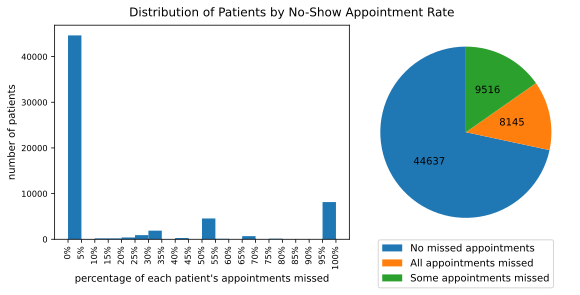

Patients who have missed no appointments: 44637
Patients who have missed all appointments: 8145
Patients who have missed a portion of their appointments: 9516


In [16]:
fig, axs = plt.subplots(
    1,
    2,
    figsize=(8, 4),
    gridspec_kw={"width_ratios": [4,3]},
    constrained_layout=True
    )

fig.suptitle("Distribution of Patients by No-Show Appointment Rate")

# Plot p_NoShow distribution
p_NoShow_axs_bins = 20
p_NoShow_axs = df_all_patients["p_NoShow"].plot.hist(
    bins=p_NoShow_axs_bins,
    xlabel="percentage of each patient's appointments missed",
    ylabel="number of patients",
    ax=axs[0]
)

xticks = np.linspace(0, 1, p_NoShow_axs_bins + 1)
xlabels = [f"{x*100:.0f}%" for x in xticks]
p_NoShow_axs.tick_params(labelsize="small")
p_NoShow_axs.tick_params("x", labelrotation=90, labelrotation_mode="xtick")
p_NoShow_axs.set_xticks(xticks, labels=xlabels)

full_attendance = df_all_patients.query("p_NoShow == 0").shape[0]
no_attendance = df_all_patients.query("p_NoShow == 1.0").shape[0]
partial_attendance = df_all_patients.query("p_NoShow > 0 and p_NoShow < 1.0").shape[0]

attendance_idx = [
        "No missed appointments",
        "All appointments missed",
        "Some appointments missed",
    ]
attendance = pd.Series(
    [full_attendance, no_attendance, partial_attendance],
    index=attendance_idx,
)

attend_ax = attendance.plot.pie(
    startangle=90,
    autopct=lambda pct: f"{int(round(pct * attendance.sum() / 100)):d}",
    pctdistance=.55,
    labels=None,
    ax=axs[1]
)
attend_ax.legend(
    attend_ax.patches,
    attendance.index,
    ncols=1,
    loc="lower center",
    bbox_to_anchor=(0.5,-0.25))
plt.show()


print(
    f"Patients who have missed no appointments: {df_all_patients.query("p_NoShow == 0").shape[0]}"
)
print(
    f"Patients who have missed all appointments: {df_all_patients.query("p_NoShow == 1.0").shape[0]}"
)
print(
    f"Patients who have missed a portion of their appointments: {df_all_patients.query("p_NoShow > 0 and p_NoShow < 1.0").shape[0]}"
)


#### Gender, FinancialAssistance, Hypertension, Diabetes, Alcoholism 

In this section we looked into whether Gender, FinancialAssistance, Hypertension, Diabetes, or Alcoholism had a statistically significant association with missed appointments - individually or collectively.



##### Statistical Analysis

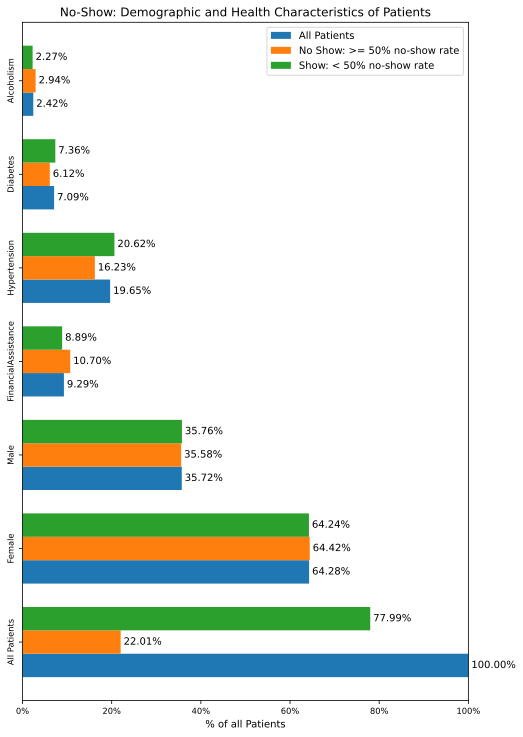

In [34]:
ax = graph_distributions(
    data=compute_distributions(
        data=df_all_patients,
        queries={
            "All Patients": None,
            "Female": "female == 1",
            "Male": "male == 1",
            "FinancialAssistance": "FinancialAssistance == 1",
            "Hypertension": "Hypertension == 1",
            "Diabetes": "Diabetes == 1",
            "Alcoholism": "Alcoholism == 1",
        },
    ),
    title="% of all Patients",
)
ax.set_title("No-Show: Demographic and Health Characteristics of Patients")

plt.show()

In [18]:
demographics_ols_model = sm.OLS(
    df_all_patients["p_NoShow"],
    df_all_patients[
        [
            "intercept",
            "FinancialAssistance",
            "Hypertension",
            "Diabetes",
            "Alcoholism",
            "female",
        ]
    ],
)
demographics_ols_results = demographics_ols_model.fit(cov_type="HC3")
print(demographics_ols_results.summary())

significant_predictors(demographics_ols_results).style.format(precision=4).set_caption("significant predictors")


                            OLS Regression Results                            
Dep. Variable:               p_NoShow   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     45.81
Date:                Fri, 18 Sep 2026   Prob (F-statistic):           2.10e-47
Time:                        12:37:56   Log-Likelihood:                -23141.
No. Observations:               62298   AIC:                         4.629e+04
Df Residuals:                   62292   BIC:                         4.635e+04
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
intercept               0.2010    

,p_value,coef
predictor,,
FinancialAssistance,0.0000,0.0309
Hypertension,0.0000,-0.0433
Alcoholism,0.0000,0.0468


##### Results

Financial Assistance, Hypertension, and Alcoholism have a statistically significant association with patient no-show rates. However, (R^2) is very low so the overall explanatory power of these demographic and health factors only accounts for 0.3% of a patients no-show rate.

#### Neighborhood

There are 81 neighborhoods recorded in the dataset. The number of patients per neighborhood varies significantly.

Neighborhoods with few patients produce imprecise no-show-rate estimates and large standard errors when using OLS. To reduce this problem, neighborhoods below a minimum patient threshold were excluded.

##### Number of Patients per Neighborhood

In [19]:
nhood_NoShow = pd.concat([
    df_all_patients.groupby("Neighborhood")["p_NoShow"].count(),
    df_all_patients.groupby("Neighborhood")["p_NoShow"].mean()
    ],
    axis=1,
    keys=[
        "num_patients",
        "p_NoShow mean"
    ])

nhood_NoShow.sort_values("num_patients", ascending=False, inplace=True)

print("all neighborhoods:")
print(value_range(nhood_NoShow, "num_patients"))

nhood_NoShow[["num_patients"]]

all neighborhoods:
num_patients:
min     max
1       4192



,num_patients
Neighborhood,
JARDIM CAMBURI,4192
MARIA ORTIZ,3336
JARDIM DA PENHA,2406
RESISTÊNCIA,2373
ITARARÉ,2136
...,...
ILHA DO BOI,22
AEROPORTO,7
ILHA DO FRADE,5


##### Small Neighborhoods

Regressions were run using 50, 100, and 200 as the minimum patient threshold. Results were consistent across all three thresholds.

In [20]:
min_patients = 100

small_neighborhoods = nhood_NoShow.query("num_patients < @min_patients")
print(f"\nsmall neighborhoods (< {min_patients} patients):")

filter_list = small_neighborhoods.index.values

print(small_neighborhoods[["num_patients"]])
print(f"\n{len(small_neighborhoods)} small neighborhoods: {small_neighborhoods[["num_patients"]].sum().values[0]} total patients")

df_all_patients_filtered = df_all_patients[~df_all_patients["Neighborhood"].isin(filter_list)]



small neighborhoods (< 100 patients):
                             num_patients
Neighborhood                             
UNIVERSITÁRIO                          93
SEGURANÇA DO LAR                       89
NAZARETH                               86
MORADA DE CAMBURI                      68
PONTAL DE CAMBURI                      45
ILHA DO BOI                            22
AEROPORTO                               7
ILHA DO FRADE                           5
ILHAS OCEÂNICAS DE TRINDADE             2
PARQUE INDUSTRIAL                       1

10 small neighborhoods: 418 total patients


##### Statistical Analysis

The largest neighborhood, in terms of number of patients, was selected as the reference category to provide a relatively stable comparison group.

In [21]:
# linear regression for neighborhood (all Patients)

# neighborhood with largest number of patients to be used as baseline
nhoods = df_all_patients_filtered["Neighborhood"].unique().tolist()
baseline_neighborhood = (
    df_all_patients_filtered["Neighborhood"]
    .value_counts()
    .idxmax()
)
print(f"baseline neighborhood: {baseline_neighborhood}\n")

predictor_neighborhoods = []
for nhood in nhoods:
    if nhood != baseline_neighborhood:
        predictor_neighborhoods.append(nhood)

patient_nhood_model_OLS = sm.OLS(
    df_all_patients_filtered["p_NoShow"],
    df_all_patients_filtered[["intercept"] + predictor_neighborhoods]
)
patient_nhood_model_OLS_results = patient_nhood_model_OLS.fit(cov_type="HC3")

print(patient_nhood_model_OLS_results.summary())

baseline neighborhood: JARDIM CAMBURI

                            OLS Regression Results                            
Dep. Variable:               p_NoShow   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     6.346
Date:                Fri, 18 Sep 2026   Prob (F-statistic):           1.50e-55
Time:                        12:37:57   Log-Likelihood:                -22850.
No. Observations:               61880   AIC:                         4.584e+04
Df Residuals:                   61809   BIC:                         4.648e+04
Df Model:                          70                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------

##### Results
Across minimum patient thresholds of 50, 100, and 200, the models consistently indicated a statistically significant association between neighborhood and patient no-show rate. However, the low `R^2` indicates that neighborhood alone has limitend explanatory power (0.7% variation of patient no-show rates).

| minimum patients | F-statistic | joint-test p-value | (R^2) |
| --- | --- | --- | --- |
| 50 | 6.054 | 1.20e-54 | 0.007 |
| 100 | 6.346 | 1.5e-55 | 0.007 |
| 200 | 7.119 | 1.45e-56 | 0.007 |


In [22]:
# Test whether all neighborhood coefficients are jointly zero
neighborhood_params = predictor_neighborhoods
parameter_names = patient_nhood_model_OLS_results.params.index

R = np.zeros((len(neighborhood_params), len(parameter_names)))

for row, neighborhood in enumerate(neighborhood_params):
    R[row, parameter_names.get_loc(neighborhood)] = 1

joint_test = patient_nhood_model_OLS_results.f_test(R)
print(f"minimum patient threshold: {min_patients}")
print(joint_test)

minimum patient threshold: 100
<F test: F=6.34567230729761, p=1.498071728066832e-55, df_denom=6.18e+04, df_num=70>


##### Significant Predictors

In [23]:
nhood_sig_p = significant_predictors(patient_nhood_model_OLS_results)

print(f"Excluding:\n{len(small_neighborhoods)} of the smallest neighborhoods (by patient count)\n{baseline_neighborhood}, which was used as the baseline")
print(f"\n{len(nhood_sig_p)} neighborhoods have no-show rates with significant differences to the reference neighborhood {baseline_neighborhood}")

nhood_sig_p.style.format(precision=4).set_caption(f"nhood significant predictors: >= {min_patients} patients")

Excluding:
10 of the smallest neighborhoods (by patient count)
JARDIM CAMBURI, which was used as the baseline

28 neighborhoods have no-show rates with significant differences to the reference neighborhood JARDIM CAMBURI


,p_value,coef
predictor,,
JARDIM DA PENHA,0.0003,-0.0309
REPÚBLICA,0.0133,-0.0369
NOVA PALESTINA,0.0423,-0.0211
SANTA MARTHA,0.0008,-0.0311
MARUÍPE,0.0022,0.0388
ILHA DAS CAIEIRAS,0.0462,0.0324
SANTO ANDRÉ,0.0365,-0.0212
MARIA ORTIZ,0.0009,0.0274
ILHA DE SANTA MARIA,0.0125,0.0326


#### Age

- TODO: graph linear regression?
- TODO: violin plots?
- TODO: results summary

##### Statistical Analysis

115


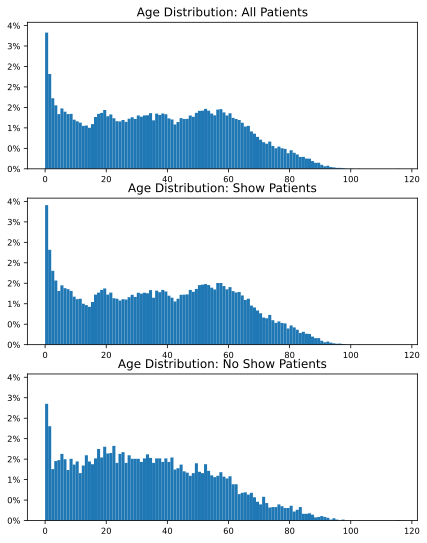

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               p_NoShow   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     332.4
Date:                Fri, 18 Sep 2026   Prob (F-statistic):           4.50e-74
Time:                        12:37:57   Log-Likelihood:                -23093.
No. Observations:               62298   AIC:                         4.619e+04
Df Residuals:                   62296   BIC:                         4.621e+04
Df Model:                           1                                         
Covariance Type:                  HC3                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.2348      0.003     88.192      0.000       0.230       0.240
Age           -0.0010   5.74e-05    -18.232      0.000      -0.001      -0.001
==============================================================================
Omnibus:                    13975.748   Durbin-Watson:                   1.801
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            25436.930
Skew:                           1.520   Prob(JB):                         0.00
Kurtosis:                       3.743   Cond. No.                         80.8
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

In [24]:
# Age histogram - try violinplot?
df_age_all = df_all_patients["Age"]
df_age_no_show = df_all_patients.query("p_NoShow > 0.5")["Age"]
df_age_show = df_all_patients.query("p_NoShow <= 0.5")["Age"]

print(df_all_patients["Age"].max())

maxAge = df_all_patients["Age"].max()
bins = maxAge + 1
range = (0, maxAge + 1)

figAge, ((ax_age_all, ax_age_show, ax_age_no_show)) = plt.subplots(
    nrows=3, ncols=1, figsize=(7, 9), sharey=True
)

ax_age_all.hist(x=df_age_all, histtype="bar", bins=bins, range=range, density=True)
ax_age_all.set_title("Age Distribution: All Patients")
ax_age_all.tick_params(labelsize="small")
ax_age_all.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))

ax_age_show.hist(x=df_age_show, histtype="bar", bins=bins, range=range, density=True)
ax_age_show.set_title("Age Distribution: Show Patients")
ax_age_show.tick_params(labelsize="small")

ax_age_no_show.hist(
    x=df_age_no_show, histtype="bar", bins=bins, range=range, density=True
)
ax_age_no_show.set_title("Age Distribution: No Show Patients")
ax_age_no_show.tick_params(labelsize="small")

plt.show()

# Age linear regression
patient_age_model_OLS = sm.OLS(
    df_all_patients["p_NoShow"],
    df_all_patients[["intercept", "Age"]]
)

patient_age_model_OLS_results = patient_age_model_OLS.fit(cov_type="HC3")
patient_age_model_OLS_results.summary()

# TODO graph Age linear regression


##### Results

#### NumHandicaps

- TODO: convert num_handcap to categorical for regression and bar graph
- TODO: results summary


##### Statistical Analysis

NumHandicaps
0    61165
1     1025
2       99
3        6
4        3
Name: count, dtype: int64


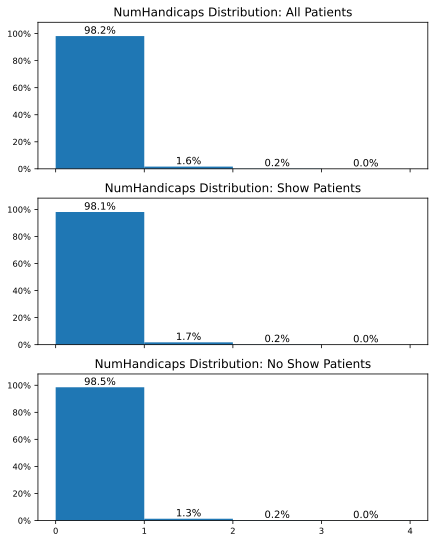

In [25]:
# NumHandicaps histogram
df_handcap_all = df_all_patients["NumHandicaps"]
df_handcap_show = df_all_patients.query("NoShow == False")["NumHandicaps"]
df_handcap_no_show = df_all_patients.query("NoShow == True")["NumHandicaps"]

print(df_handcap_all.value_counts())

xticks = np.linspace(0, 4, 5)
p_NoShow_axs.set_xticks(xticks);

bins = np.linspace(0, 4, 5)
range = (0, 5)

fig_num_handicaps, ((ax_handcap_all, ax_handcap_show, ax_handcap_no_show)) = (
    plt.subplots(nrows=3, ncols=1, figsize=(7, 9), sharey=True, sharex=True)
)

counts_all, bins_all, patches_all = ax_handcap_all.hist(
    x=df_handcap_all, histtype="bar", bins=bins, range=range, density=True
)
ax_handcap_all.set_title("NumHandicaps Distribution: All Patients")
ax_handcap_all.set_xticks(xticks)
ax_handcap_all.tick_params(labelsize="small")
ax_handcap_all.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
ax_handcap_all.bar_label(
    patches_all, fmt=lambda x: f"{x * 100:.1f}%", label_type="edge"
)
ax_handcap_all.margins(y=0.1)

counts_show, bins_show, patches_show = ax_handcap_show.hist(
    x=df_handcap_show, histtype="bar", bins=bins, range=range, density=True
)
ax_handcap_show.set_title("NumHandicaps Distribution: Show Patients")
ax_handcap_show.set_xticks(xticks)
ax_handcap_show.tick_params(labelsize="small")
ax_handcap_show.bar_label(
    patches_show, fmt=lambda x: f"{x * 100:.1f}%", label_type="edge"
)
ax_handcap_show.margins(y=0.1)

counts_no_show, bins_no_show, patches_no_show = ax_handcap_no_show.hist(
    x=df_handcap_no_show,
    histtype="bar",
    bins=bins,
    range=range,
    density=True
)
ax_handcap_no_show.set_title("NumHandicaps Distribution: No Show Patients")
ax_handcap_no_show.set_xticks(xticks)
ax_handcap_no_show.tick_params(labelsize="small")
ax_handcap_no_show.bar_label(
    patches_no_show, fmt=lambda x: f"{x * 100:.1f}%", label_type="edge"
)
ax_handcap_no_show.margins(0.1)

plt.show()

# NumHandicaps linear regression
# TODO convert to categorical for regression calc and distribution graph

##### Results

#### Conclusion


### Do any factors related to the appointment correlate with a higher likelihood of a missed appointment?

#### Appointment factors
- `SchedulingDate_day_name` - day of week
- `AppointmentDate_day_name` - day of week
- number of days between `SchedulingDate` and `AppointmentDate`
- `SMS_received`
- number of appointments per `PatientId`
- has patient previously missed an appointment?

#### SchedulingDate_day_name

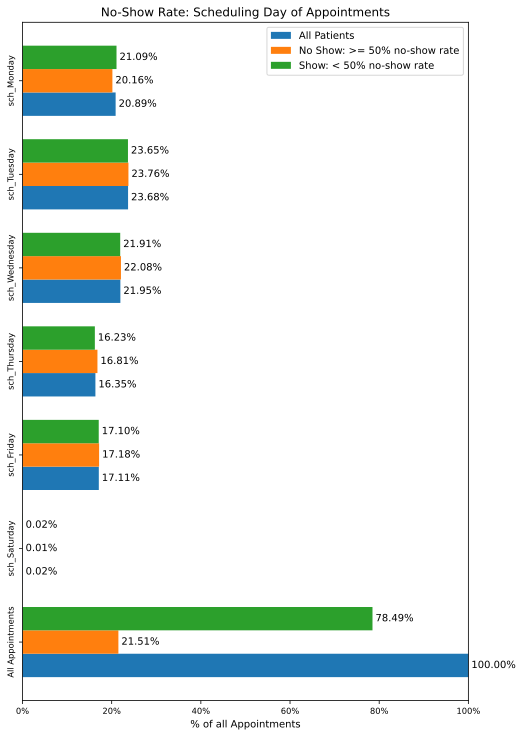

                            OLS Regression Results                            
Dep. Variable:               p_NoShow   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     2.356
Date:                Fri, 18 Sep 2026   Prob (F-statistic):             0.0379
Time:                        12:37:58   Log-Likelihood:                -28795.
No. Observations:              110521   AIC:                         5.760e+04
Df Residuals:                  110515   BIC:                         5.766e+04
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
intercept         0.1146      0.040      2.891

,p_value,coef
predictor,,
sch_Monday,0.0353,0.0835
sch_Tuesday,0.0259,0.0884
sch_Wednesday,0.0282,0.0871
sch_Thursday,0.0212,0.0915
sch_Friday,0.0286,0.0869


In [ ]:
ax = graph_distributions(
    data=compute_distributions(
        data=df_all_appointments,
        queries={
            "All Appointments": None,
            "sch_Saturday": "sch_Saturday == 1",
            "sch_Friday": "sch_Friday == 1",
            "sch_Thursday": "sch_Thursday == 1",
            "sch_Wednesday": "sch_Wednesday == 1",
            "sch_Tuesday": "sch_Tuesday == 1",
            "sch_Monday": "sch_Monday == 1",
        },
    ),
    title="% of all Appointments",
)
ax.set_title("No-Show: Scheduling Day of Appointments")

plt.show()

# linear regression: schedule days
# baseline for SchedulingDate_day_name dummies: Saturday (Sunday not present in data)
schedule_day_model = sm.OLS(
    df_all_appointments["p_NoShow"],
    df_all_appointments[
        [
            "intercept",
            "sch_Monday",
            "sch_Tuesday",
            "sch_Wednesday",
            "sch_Thursday",
            "sch_Friday",
        ]
    ],
)
schedule_day_results = schedule_day_model.fit(cov_type="HC3")

print(schedule_day_results.summary())
significant_predictors(schedule_day_results).style.format(precision=4).set_caption(
    "significant predictors"
)

#### AppointmentDate_day_name

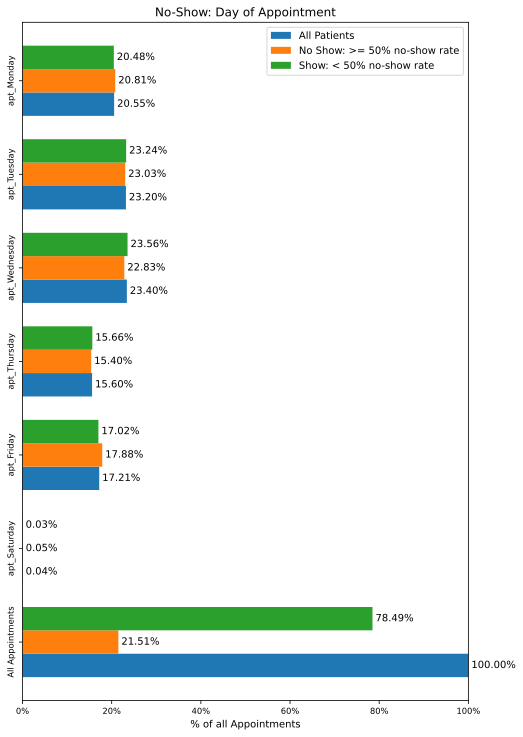

                            OLS Regression Results                            
Dep. Variable:               p_NoShow   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     4.732
Date:                Fri, 18 Sep 2026   Prob (F-statistic):           0.000252
Time:                        12:37:58   Log-Likelihood:                -28787.
No. Observations:              110521   AIC:                         5.759e+04
Df Residuals:                  110515   BIC:                         5.764e+04
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
intercept         0.2158      0.052      4.117

,p_value,coef
predictor,,


In [27]:
ax = graph_distributions(
    data=compute_distributions(
        data=df_all_appointments,
        queries={
            "All Appointments": None,
            "apt_Saturday": "apt_Saturday == 1",
            "apt_Friday": "apt_Friday == 1",
            "apt_Thursday": "apt_Thursday == 1",
            "apt_Wednesday": "apt_Wednesday == 1",
            "apt_Tuesday": "apt_Tuesday == 1",
            "apt_Monday": "apt_Monday == 1",
        },
    ),
    title="% of all Appointments",
)
ax.set_title("No-Show: Day of Appointment")

plt.show()

# linear regression: appointment days
# baseline for AppointmentDate_day_name: Saturday (Sunday not present in data)
appointment_day_model = sm.OLS(
    df_all_appointments["p_NoShow"],
    df_all_appointments[
        [
            "intercept",
            "apt_Monday",
            "apt_Tuesday",
            "apt_Wednesday",
            "apt_Thursday",
            "apt_Friday",
        ]
    ],
)
appointment_day_results = appointment_day_model.fit(cov_type="HC3")

print(appointment_day_results.summary())
significant_predictors(appointment_day_results).style.format(precision=4).set_caption(
    "significant predictors"
)

#### num_days

In [28]:
# scatter plot

# logistic regression for num_days
num_days_model = sm.OLS(
    df_all_appointments["p_NoShow"], df_all_appointments[["intercept", "num_days"]]
)
num_days_results = num_days_model.fit(cov_type="HC3")

print(num_days_results.summary())

print(f"significant predictors\n{significant_predictors(num_days_results)}")

# TODO: graph linear regression

                            OLS Regression Results                            
Dep. Variable:               p_NoShow   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     1856.
Date:                Fri, 18 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:37:58   Log-Likelihood:                -27348.
No. Observations:              110521   AIC:                         5.470e+04
Df Residuals:                  110519   BIC:                         5.472e+04
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.1681      0.001    160.790      0.0

#### SMS_Received

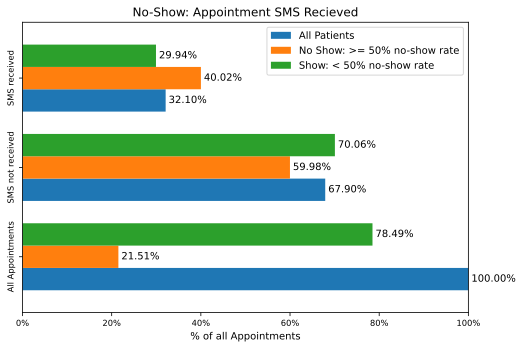

                            OLS Regression Results                            
Dep. Variable:               p_NoShow   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     994.7
Date:                Fri, 18 Sep 2026   Prob (F-statistic):          2.31e-217
Time:                        12:37:58   Log-Likelihood:                -28250.
No. Observations:              110521   AIC:                         5.650e+04
Df Residuals:                  110519   BIC:                         5.652e+04
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept        0.1804      0.001    166.685   

,p_value,coef
predictor,,
SMS_received,0.0000,0.0669


In [29]:
ax = graph_distributions(
    data=compute_distributions(
        data=df_all_appointments,
        queries={
            "All Appointments": None,
            "SMS not received": "SMS_received == 0",
            "SMS received": "SMS_received == 1",
        },
    ),
    title="% of all Appointments",
)
ax.set_title("No-Show: Appointment SMS Recieved")

plt.show()

sms_model = sm.OLS(
    df_all_appointments["p_NoShow"], df_all_appointments[["intercept", "SMS_received"]]
)
sms_results = sms_model.fit(cov_type="HC3")

print(sms_results.summary())
print("\nsignificant predictors")
significant_predictors(sms_results).style.format(precision=4)

In [30]:
# number of appointments per patient

In [31]:
# has patient previously missed an appointment

In [32]:
# Continue to explore the data to address your additional research
#   questions. Add more headers as needed if you have more questions to
#   investigate.

<a id='conclusions'></a>
## Conclusions

> **Tip**: Finally, summarize your findings and the results that have been performed in relation to the question(s) provided at the beginning of the analysis. Summarize the results accurately, and point out where additional research can be done or where additional information could be useful.

> **Tip**: Make sure that you are clear with regards to the limitations of your exploration. You should have at least 1 limitation explained clearly. 

> **Tip**: If you haven't done any statistical tests, do not imply any statistical conclusions. And make sure you avoid implying causation from correlation!

> **Tip**: Once you are satisfied with your work here, check over your report to make sure that it is satisfies all the areas of the rubric (found on the project submission page at the end of the lesson). You should also probably remove all of the "Tips" like this one so that the presentation is as polished as possible.

## Submitting your Project 

> **Tip**: Before you submit your project, you need to create a .html or .pdf version of this notebook in the workspace here. To do that, run the code cell below. If it worked correctly, you should see output that starts with `NbConvertApp] Converting notebook`, and you should see the generated .html file in the workspace directory (click on the orange Jupyter icon in the upper left).

> **Tip**: Alternatively, you can download this report as .html via the **File** > **Download as** submenu, and then manually upload it into the workspace directory by clicking on the orange Jupyter icon in the upper left, then using the Upload button.

> **Tip**: Once you've done this, you can submit your project by clicking on the "Submit Project" button in the lower right here. This will create and submit a zip file with this .ipynb doc and the .html or .pdf version you created. Congratulations!

In [33]:
# Running this cell will execute a bash command to convert this notebook to an .html file
#!python -m nbconvert --to html Investigate_a_Dataset.ipynb